# Capstone Project — Job Title Prediction
## AI Engineer Tech Stack: MLP with TensorFlow Functional API

**Task:** Multiclass classification untuk prediksi `job_title` (20 kelas)  
**Input:** 97 fitur hasil preprocessing Data Science pipeline  
**Stack:** TensorFlow Functional API · Custom Layer · Custom Loss · Custom Callback · TensorBoard · FastAPI


## 1. Setup & Import

In [ ]:

import os, json, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, backend as K
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow version : 2.20.0
GPU available      : False


## 2. Load Data & Artefak Preprocessing

In [ ]:
X_train = pd.read_csv('X_train.csv').values.astype(np.float32)
X_val   = pd.read_csv('X_val.csv').values.astype(np.float32)
X_test  = pd.read_csv('X_test.csv').values.astype(np.float32)

y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')
y_test  = np.load('y_test.npy')

label_encoder = joblib.load('label_encoder_job_title.pkl')

NUM_FEATURES = X_train.shape[1]
NUM_CLASSES  = len(label_encoder.classes_)
CLASS_NAMES  = label_encoder.classes_.tolist()

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {NUM_CLASSES}  →  {CLASS_NAMES[:5]} ...")

X_train : (30000, 97)
X_val   : (10000, 97)
X_test  : (10000, 97)
Classes : 20  →  ['Backend Developer', 'Business Analyst', 'Cloud Architect', 'Cybersecurity Analyst', 'Data Analyst'] ...


## 3. Custom Components

> **Main Quest requirement:** minimal satu Custom Layer, Custom Loss Function, dan Custom Callback.

### 3.1 Custom Layer, `ResidualBlock`

In [ ]:
class ResidualBlock(layers.Layer):
    """Dense → BN → ReLU → Dropout → Dense → BN + skip connection."""

    def __init__(self, units: int, dropout_rate: float = 0.3,
                 l2: float = 1e-4, **kwargs):
        super().__init__(**kwargs)
        self.units        = units
        self.dropout_rate = dropout_rate

        self.dense1 = layers.Dense(
            units, kernel_regularizer=regularizers.l2(l2))
        self.bn1    = layers.BatchNormalization()
        self.act1   = layers.Activation('relu')
        self.drop1  = layers.Dropout(dropout_rate)

        self.dense2 = layers.Dense(
            units, kernel_regularizer=regularizers.l2(l2))
        self.bn2    = layers.BatchNormalization()

        self.projection = layers.Dense(units, use_bias=False)
        self.bn_proj    = layers.BatchNormalization()
        self.act_out    = layers.Activation('relu')

    def call(self, x, training=False):

        h = self.dense1(x)
        h = self.bn1(h, training=training)
        h = self.act1(h)
        h = self.drop1(h, training=training)
        h = self.dense2(h)
        h = self.bn2(h, training=training)


        skip = self.projection(x)
        skip = self.bn_proj(skip, training=training)

        return self.act_out(h + skip)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units, 'dropout_rate': self.dropout_rate})
        return cfg

print("ResidualBlock defined ✓")

ResidualBlock defined ✓


### 3.2 Custom Loss, `LabelSmoothingCategoricalCrossentropy`

In [ ]:
class LabelSmoothingCategoricalCrossentropy(keras.losses.Loss):
    """Categorical cross-entropy with label smoothing to prevent overconfidence."""
    def __init__(self, num_classes: int, smoothing: float = 0.1,
             name: str = 'label_smoothing_cce', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def call(self, y_true, y_pred):

        y_true_oh = tf.one_hot(
            tf.cast(tf.squeeze(y_true), tf.int32), self.num_classes)

        y_smooth = (
            y_true_oh * (1.0 - self.smoothing) +
            self.smoothing / self.num_classes
        )

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        return -tf.reduce_mean(
            tf.reduce_sum(y_smooth * tf.math.log(y_pred), axis=-1)
        )

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_classes': self.num_classes, 'smoothing': self.smoothing})
        return cfg

print("LabelSmoothingCategoricalCrossentropy defined ✓")

LabelSmoothingCategoricalCrossentropy defined ✓


### 3.3 Custom Callback — `TrainingLogger`

In [ ]:
class TrainingLogger(keras.callbacks.Callback):
    """Log metrics per epoch to CSV and print a formatted summary."""

    def __init__(self, log_path: str = 'training_log.csv'):
        super().__init__()
        self.log_path = log_path
        self.records  = []

    def on_train_begin(self, logs=None):
        print(f"{'Epoch':>6} {'Loss':>10} {'Val Loss':>10} "
              f"{'Acc':>8} {'Val Acc':>8} {'LR':>10}")
        print("-" * 60)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr   = float(K.get_value(self.model.optimizer.learning_rate))
        row  = {
            'epoch'    : epoch + 1,
            'loss'     : logs.get('loss', 0),
            'val_loss' : logs.get('val_loss', 0),
            'accuracy' : logs.get('accuracy', 0),
            'val_accuracy': logs.get('val_accuracy', 0),
            'lr'       : lr,
        }
        self.records.append(row)
        print(f"{row['epoch']:>6} {row['loss']:>10.4f} {row['val_loss']:>10.4f} "
              f"{row['accuracy']:>8.4f} {row['val_accuracy']:>8.4f} {lr:>10.2e}")

    def on_train_end(self, logs=None):
        pd.DataFrame(self.records).to_csv(self.log_path, index=False)
        print(f"\nTraining log saved → {self.log_path}")

print("TrainingLogger defined ✓")

TrainingLogger defined ✓


## 4. Model Architecture — MLP dengan Functional API

 MLP Classifier menggunakan TensorFlow Functional API.

    Arsitektur:
        Input → BN → Dense(512) → ResidualBlock(256) → ResidualBlock(128)
             → Dropout → Dense(num_classes, softmax)

In [ ]:
def build_mlp_model(
    num_features : int,
    num_classes  : int,
    hidden_units : list = [512, 256, 128],
    dropout_rate : float = 0.3,
    l2_reg       : float = 1e-4,
    learning_rate: float = 1e-3,
) -> keras.Model:

    inputs = keras.Input(shape=(num_features,), name='features')

    x = layers.BatchNormalization(name='input_bn')(inputs)

    x = layers.Dense(
        hidden_units[0],
        kernel_regularizer=regularizers.l2(l2_reg),
        name='dense_entry'
    )(x)
    x = layers.BatchNormalization(name='bn_entry')(x)
    x = layers.Activation('relu', name='act_entry')(x)
    x = layers.Dropout(dropout_rate, name='drop_entry')(x)

    for i, units in enumerate(hidden_units[1:], start=1):
        x = ResidualBlock(
            units, dropout_rate=dropout_rate, l2=l2_reg,
            name=f'residual_block_{i}'
        )(x)

    x = layers.Dropout(dropout_rate * 0.5, name='drop_head')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='MLP_ResNet')

    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=learning_rate, weight_decay=l2_reg
        ),
        loss=LabelSmoothingCategoricalCrossentropy(
            num_classes=num_classes, smoothing=0.1
        ),
        metrics=['accuracy']
    )
    return model

model = build_mlp_model(
    num_features  = NUM_FEATURES,
    num_classes   = NUM_CLASSES,
    hidden_units  = [512, 256, 128],
    dropout_rate  = 0.3,
    learning_rate = 1e-3,
)

model.summary(line_length=80)

Model: "MLP_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)             │ (None, 97)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ input_bn (BatchNormalization)     │ (None, 97)               │           388 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_entry (Dense)               │ (None, 512)              │        50,176 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn_entry (BatchNormalization)     │ (None, 512)              │         2,048 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ act_entry (Activation)            │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop_entry (Dropout)              │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ residual_block_1 (ResidualBlock)  │ (None, 256)              │       331,264 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ residual_block_2 (ResidualBlock)  │ (None, 128)              │        83,712 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop_head (Dropout)               │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ output (Dense)                    │ (None, 20)               │         2,580 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 470,168 (1.79 MB)

 Trainable params: 466,646 (1.78 MB)

 Non-trainable params: 3,522 (13.76 KB)

## 5. Training Setup

In [ ]:
LOG_DIR = os.path.join(
    'tb_logs',
    datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
)

callbacks = [
    TrainingLogger(log_path='training_log.csv'),

    TensorBoard(
        log_dir=LOG_DIR,
        histogram_freq=1,
        write_graph=True,
        update_freq='epoch'
    ),

    ModelCheckpoint(
        filepath='best_mlp_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),

    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
]

print(f"TensorBoard log dir : {LOG_DIR}")
print(f"Total callbacks     : {len(callbacks)}")

TensorBoard log dir : tb_logs/20260529_004704
Total callbacks     : 5


## 6. Training dengan Custom tf.GradientTape Loop

> Implementasi training loop manual menggunakan `tf.GradientTape` dari awal.
> Model terbaik langsung disimpan sebagai artefak produksi (`.keras` + `SavedModel`).

In [ ]:
BATCH_SIZE = 256

def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.int32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")

Train batches : 118
Val batches   : 40


In [ ]:
gt_model = build_mlp_model(
    num_features  = NUM_FEATURES,
    num_classes   = NUM_CLASSES,
    hidden_units  = [512, 256, 128],
    dropout_rate  = 0.3,
    learning_rate = 1e-3,
)

loss_fn   = LabelSmoothingCategoricalCrossentropy(NUM_CLASSES, smoothing=0.1)
optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

train_loss_metric = keras.metrics.Mean(name='train_loss')
train_acc_metric  = keras.metrics.SparseCategoricalAccuracy(name='train_acc')
val_loss_metric   = keras.metrics.Mean(name='val_loss')
val_acc_metric    = keras.metrics.SparseCategoricalAccuracy(name='val_acc')

GT_LOG_DIR = os.path.join(
    'tb_logs_gradtape',
    datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
)
gt_train_writer = tf.summary.create_file_writer(os.path.join(GT_LOG_DIR, 'train'))
gt_val_writer   = tf.summary.create_file_writer(os.path.join(GT_LOG_DIR, 'val'))
print(f"GradientTape TensorBoard log dir : {GT_LOG_DIR}")


@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = gt_model(x_batch, training=True)
        loss   = loss_fn(y_batch, logits)
    grads = tape.gradient(loss, gt_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, gt_model.trainable_variables))
    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(y_batch, logits)


@tf.function
def val_step(x_batch, y_batch):
    logits = gt_model(x_batch, training=False)
    loss   = loss_fn(y_batch, logits)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y_batch, logits)


EPOCHS        = 60
PATIENCE      = 10
best_val_acc  = 0.0
no_improve    = 0
gt_history    = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

# ReduceLROnPlateau state
current_lr    = 1e-3
lr_patience   = 5
lr_no_improve = 0
best_val_loss = float('inf')
LR_FACTOR     = 0.5
LR_MIN        = 1e-6

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9} {'LR':>10}")
print("-" * 65)

for epoch in range(EPOCHS):
    for xb, yb in train_ds:
        train_step(xb, yb)
    for xb, yb in val_ds:
        val_step(xb, yb)

    t_loss = train_loss_metric.result().numpy()
    t_acc  = train_acc_metric.result().numpy()
    v_loss = val_loss_metric.result().numpy()
    v_acc  = val_acc_metric.result().numpy()

    gt_history['loss'].append(t_loss)
    gt_history['accuracy'].append(t_acc)
    gt_history['val_loss'].append(v_loss)
    gt_history['val_accuracy'].append(v_acc)


    with gt_train_writer.as_default():
        tf.summary.scalar('loss',     t_loss,      step=epoch)
        tf.summary.scalar('accuracy', t_acc,        step=epoch)
        tf.summary.scalar('lr',       current_lr,   step=epoch)
    with gt_val_writer.as_default():
        tf.summary.scalar('loss',     v_loss, step=epoch)
        tf.summary.scalar('accuracy', v_acc,  step=epoch)

    print(f"{epoch+1:>6} {t_loss:>12.4f} {t_acc:>10.4f} {v_loss:>10.4f} {v_acc:>9.4f} {current_lr:>10.2e}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        lr_no_improve = 0
    else:
        lr_no_improve += 1
        if lr_no_improve >= lr_patience:
            new_lr = max(current_lr * LR_FACTOR, LR_MIN)
            if new_lr < current_lr:
                current_lr = new_lr
                optimizer.learning_rate.assign(current_lr)
                print(f"  ReduceLR -> lr = {current_lr:.2e}")
            lr_no_improve = 0

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        gt_model.save('best_mlp_gradtape.keras')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}. Best val_acc: {best_val_acc:.4f}")
            break

    for m in [train_loss_metric, train_acc_metric, val_loss_metric, val_acc_metric]:
        m.reset_state()

print(f"\nBest val_accuracy (GradientTape): {best_val_acc:.4f}")
print(f"TensorBoard logs tersimpan di   : {GT_LOG_DIR}")


final_model = keras.models.load_model(
    'best_mlp_gradtape.keras',
    custom_objects={
        'ResidualBlock': ResidualBlock,
        'LabelSmoothingCategoricalCrossentropy': LabelSmoothingCategoricalCrossentropy,
    }
)

final_model.save('mlp_job_title.keras')
print("Saved -> mlp_job_title.keras")

final_model.export('mlp_job_title_savedmodel')
print("Saved -> mlp_job_title_savedmodel/")

metadata = {
    'model_name'   : 'MLP_ResNet',
    'num_features' : NUM_FEATURES,
    'num_classes'  : NUM_CLASSES,
    'class_names'  : CLASS_NAMES,
    'trained_with' : 'tf.GradientTape',
    'best_val_acc' : float(best_val_acc),
    'test_accuracy': None,
    'saved_at'     : datetime.datetime.now().isoformat(),
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Saved -> model_metadata.json")
print("\n✓ Artefak produksi dari GradientTape loop berhasil disimpan.")


GradientTape TensorBoard log dir : tb_logs_gradtape/20260529_004705
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc         LR
-----------------------------------------------------------------
     1       0.8841     0.9310     0.9775    0.9525   1.00e-03
     2       0.6925     0.9771     0.6571    0.9751   1.00e-03
     3       0.6717     0.9796     0.6389    0.9772   1.00e-03
     4       0.6607     0.9797     0.6375    0.9769   1.00e-03
     5       0.6568     0.9790     0.6371    0.9750   1.00e-03
     6       0.6522     0.9787     0.6377    0.9772   1.00e-03
     7       0.6492     0.9801     0.6351    0.9768   1.00e-03
     8       0.6463     0.9804     0.6351    0.9754   1.00e-03
     9       0.6456     0.9799     0.6342    0.9760   1.00e-03
    10       0.6436     0.9806     0.6366    0.9763   1.00e-03
    11       0.6421     0.9810     0.6345    0.9755   1.00e-03
    12       0.6401     0.9815     0.6335    0.9759   1.00e-03
    13       0.6398     0.9813     0.6335    0.

## 7. Visualisasi Training History

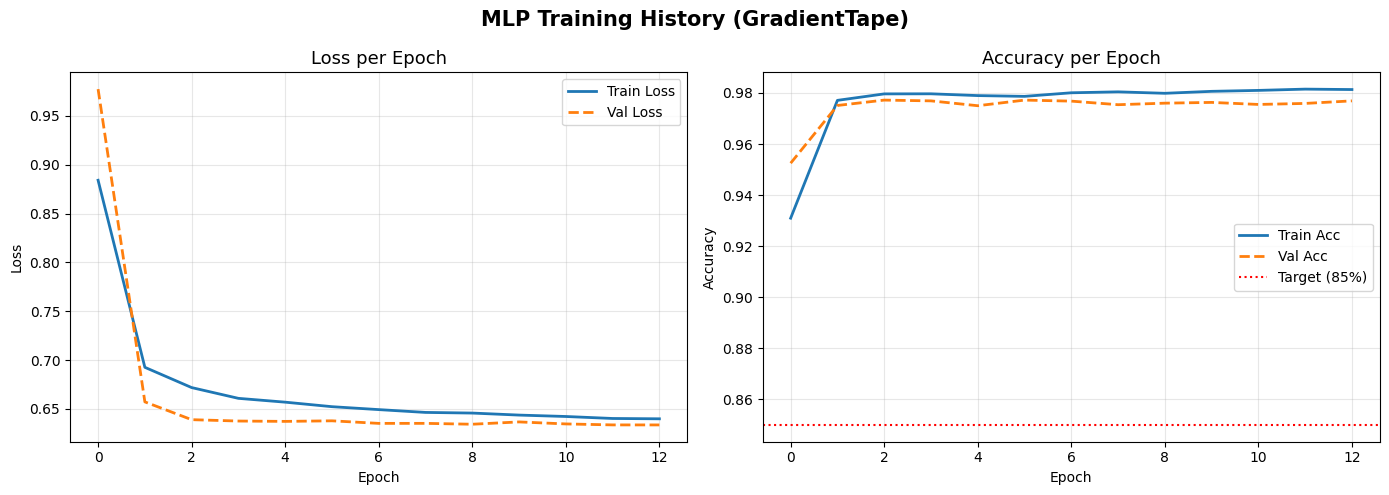

Saved -> training_history.png


In [ ]:
def plot_history(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history['loss'],     label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    axes[0].set_title('Loss per Epoch', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history['accuracy'],     label='Train Acc', linewidth=2)
    axes[1].plot(history['val_accuracy'], label='Val Acc',   linewidth=2, linestyle='--')
    axes[1].axhline(0.85, color='red', linestyle=':', label='Target (85%)')
    axes[1].set_title('Accuracy per Epoch', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('MLP Training History (GradientTape)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved -> training_history.png")

plot_history(gt_history)


## 8. Evaluasi Model

In [ ]:

best_model = keras.models.load_model(
    'mlp_job_title.keras',
    custom_objects={
        'ResidualBlock': ResidualBlock,
        'LabelSmoothingCategoricalCrossentropy': LabelSmoothingCategoricalCrossentropy,
    }
)

y_pred_prob = best_model.predict(X_test, batch_size=512, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"\n{'='*55}")
print(f"  TEST ACCURACY : {test_acc*100:.2f}%")
print(f"{'='*55}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

with open('model_metadata.json') as f:
    metadata = json.load(f)
metadata['test_accuracy'] = float(test_acc)
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("model_metadata.json updated dengan test_accuracy ok")



  TEST ACCURACY : 97.60%

                           precision    recall  f1-score   support

        Backend Developer       0.83      0.99      0.90       502
         Business Analyst       0.99      1.00      1.00       515
          Cloud Architect       1.00      1.00      1.00       500
    Cybersecurity Analyst       1.00      1.00      1.00       508
             Data Analyst       0.96      0.99      0.97       498
            Data Engineer       1.00      0.98      0.99       488
           Data Scientist       0.97      0.96      0.97       499
          DevOps Engineer       0.95      0.93      0.94       499
        Financial Analyst       1.00      0.99      1.00       497
       Frontend Developer       1.00      1.00      1.00       482
               HR Manager       1.00      1.00      1.00       488
Machine Learning Engineer       0.99      0.99      0.99       507
        Marketing Manager       1.00      1.00      1.00       503
       Operations Manager       1.

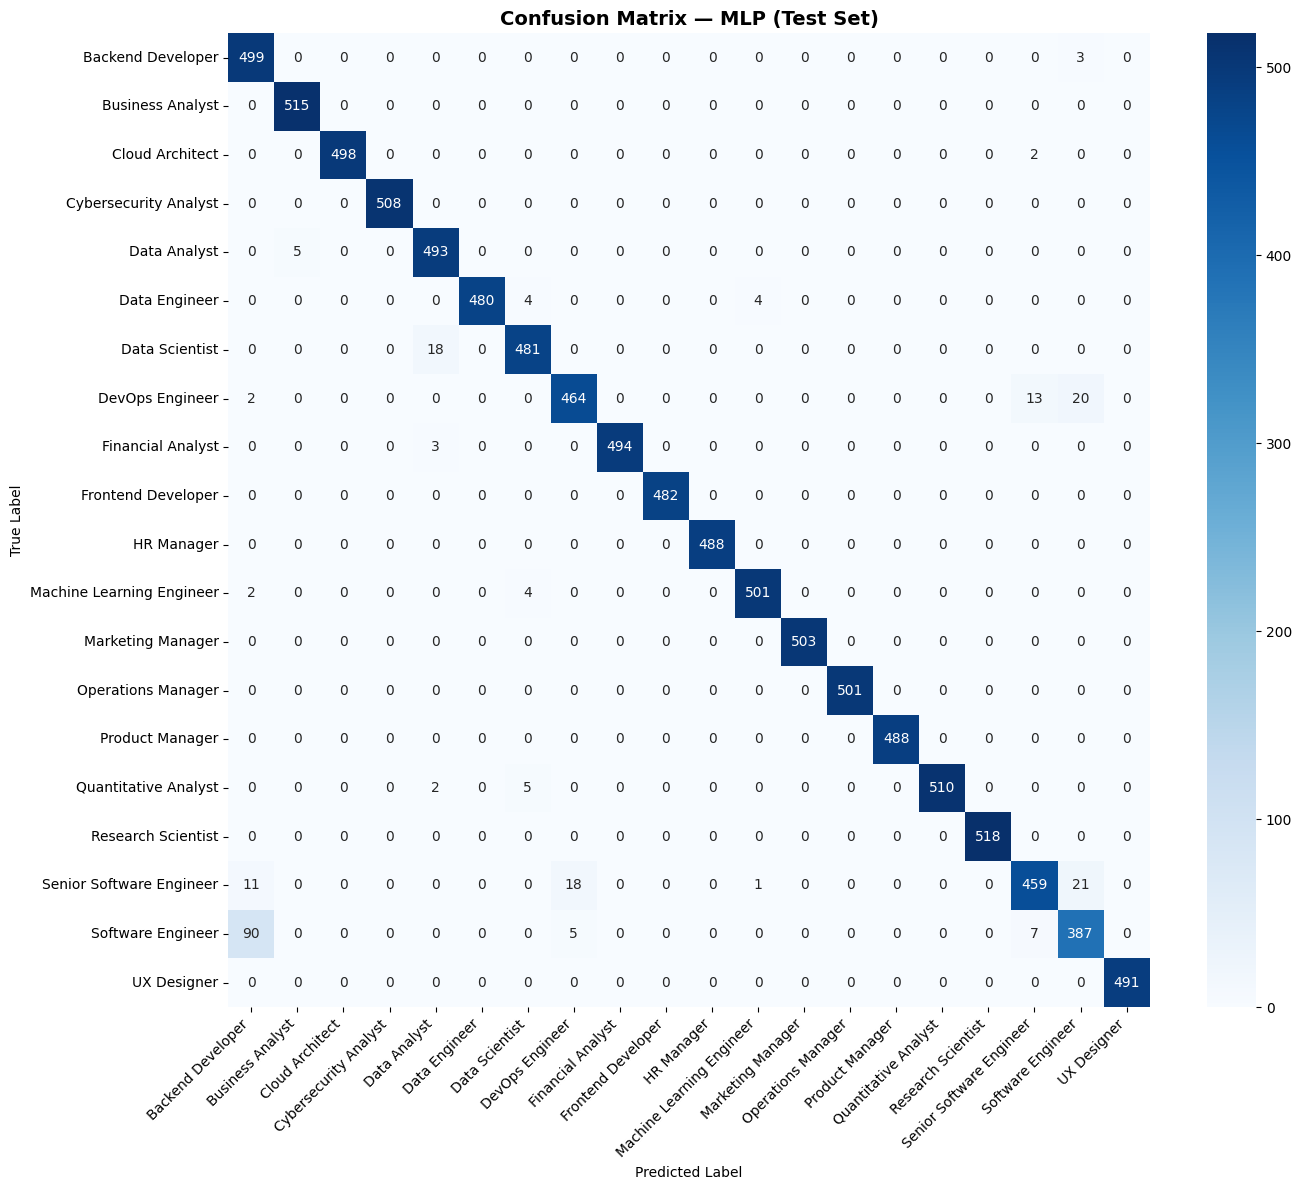

Saved → confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix — MLP (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → confusion_matrix.png")

## 9. Simpan Model — Konfirmasi Artefak

In [ ]:
import os

artefacts = [
    'mlp_job_title.keras',
    'mlp_job_title_savedmodel',
    'model_metadata.json',
    'best_mlp_gradtape.keras',
]
print("Artefak produksi:")
for a in artefacts:
    status = "ok" if os.path.exists(a) else "NOT FOUND"
    print(f"  [{status}]  {a}")


Artefak produksi:
  [ok]  mlp_job_title.keras
  [ok]  mlp_job_title_savedmodel
  [ok]  model_metadata.json
  [ok]  best_mlp_gradtape.keras


## 10. Inference — Kode Sederhana

In [ ]:
_INFER_MODEL = keras.models.load_model(
    'mlp_job_title.keras',
    custom_objects={
        'ResidualBlock': ResidualBlock,
        'LabelSmoothingCategoricalCrossentropy': LabelSmoothingCategoricalCrossentropy,
    }
)
print("Inference model loaded (global) ok")


def predict_job_title(
    features: np.ndarray,
    top_k: int = 3
) -> dict:
    """
    Prediksi job_title dari feature vector.

    Parameters
    ----------
    features : np.ndarray, shape (101,) atau (N, 101)
    top_k    : jumlah top prediksi yang dikembalikan

    Returns
    -------
    dict dengan 'predicted', 'confidence', 'top_k'

    Notes
    -----
    Model di-load sekali saat modul diimport (_INFER_MODEL global),
    bukan setiap kali fungsi dipanggil, sehingga efisien untuk produksi.
    """
    x     = np.atleast_2d(features).astype(np.float32)
    probs = _INFER_MODEL.predict(x, verbose=0)

    top_idx = np.argsort(probs, axis=1)[:, ::-1][:, :top_k]
    results = []
    for i in range(len(x)):
        results.append({
            'predicted'  : CLASS_NAMES[top_idx[i, 0]],
            'confidence' : float(probs[i, top_idx[i, 0]]),
            'top_k'      : [
                {'rank': r+1, 'job_title': CLASS_NAMES[top_idx[i, r]],
                 'probability': float(probs[i, top_idx[i, r]])}
                for r in range(top_k)
            ]
        })
    return results[0] if len(x) == 1 else results


sample_features = X_test[0]
result = predict_job_title(sample_features, top_k=3)

print("=== Inference Result ===")
print(f"  Ground truth : {CLASS_NAMES[y_test[0]]}")
print(f"  Predicted    : {result['predicted']}")
print(f"  Confidence   : {result['confidence']:.2%}")
print("  Top-3:")
for r in result['top_k']:
    print(f"    {r['rank']}. {r['job_title']:<35} {r['probability']:.2%}")


Inference model loaded (global) ok
=== Inference Result ===
  Ground truth : Senior Software Engineer
  Predicted    : Senior Software Engineer
  Confidence   : 91.14%
  Top-3:
    1. Senior Software Engineer            91.14%
    2. Software Engineer                   1.44%
    3. Machine Learning Engineer           0.98%


In [ ]:
pip freeze > requirements.txt